In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

df.head()



,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])



Rows: 10000
Columns: 12


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [6]:

df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [7]:

print(df['churn'].value_counts())



churn
0    7963
1    2037
Name: count, dtype: int64


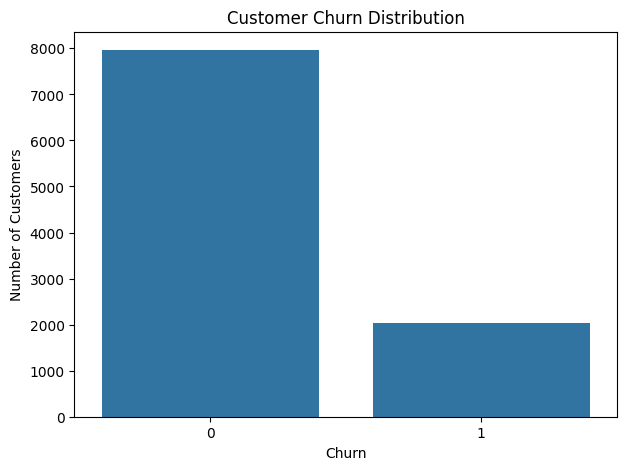

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='churn'
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()


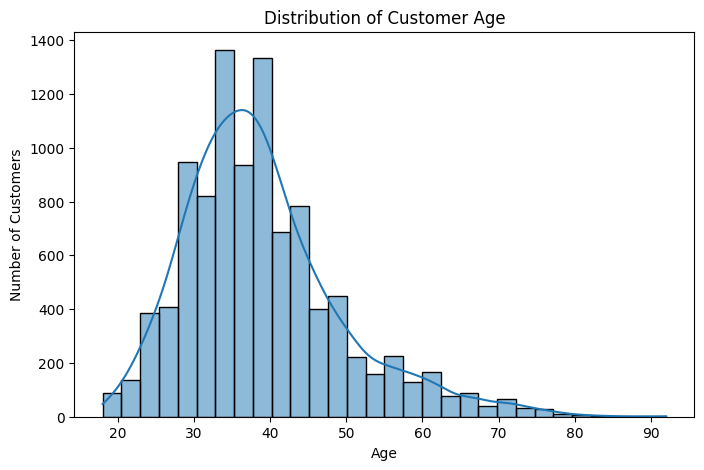

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()



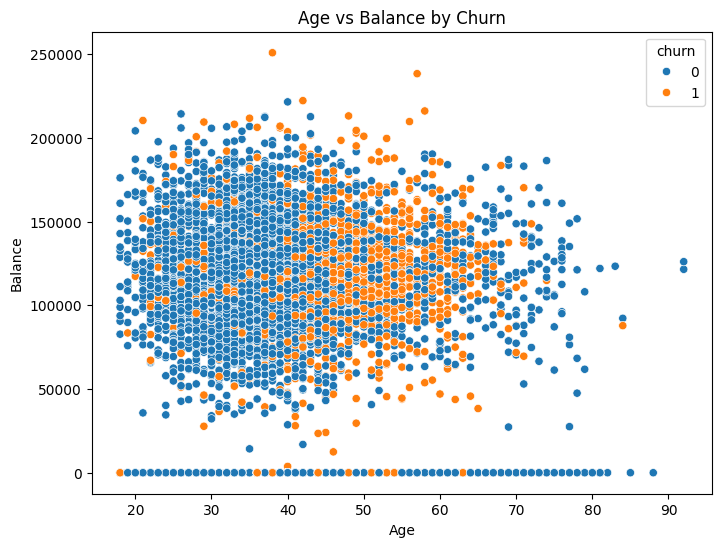

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='balance',
    hue='churn'
)

plt.title('Age vs Balance by Churn')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()

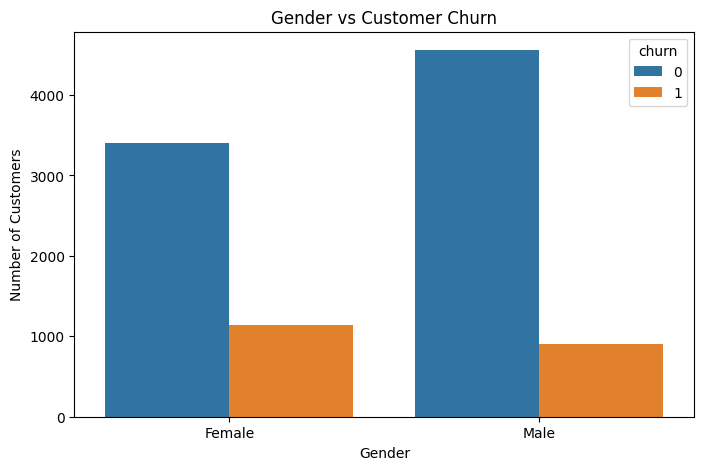

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='gender',
    hue='churn'
)

plt.title('Gender vs Customer Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()



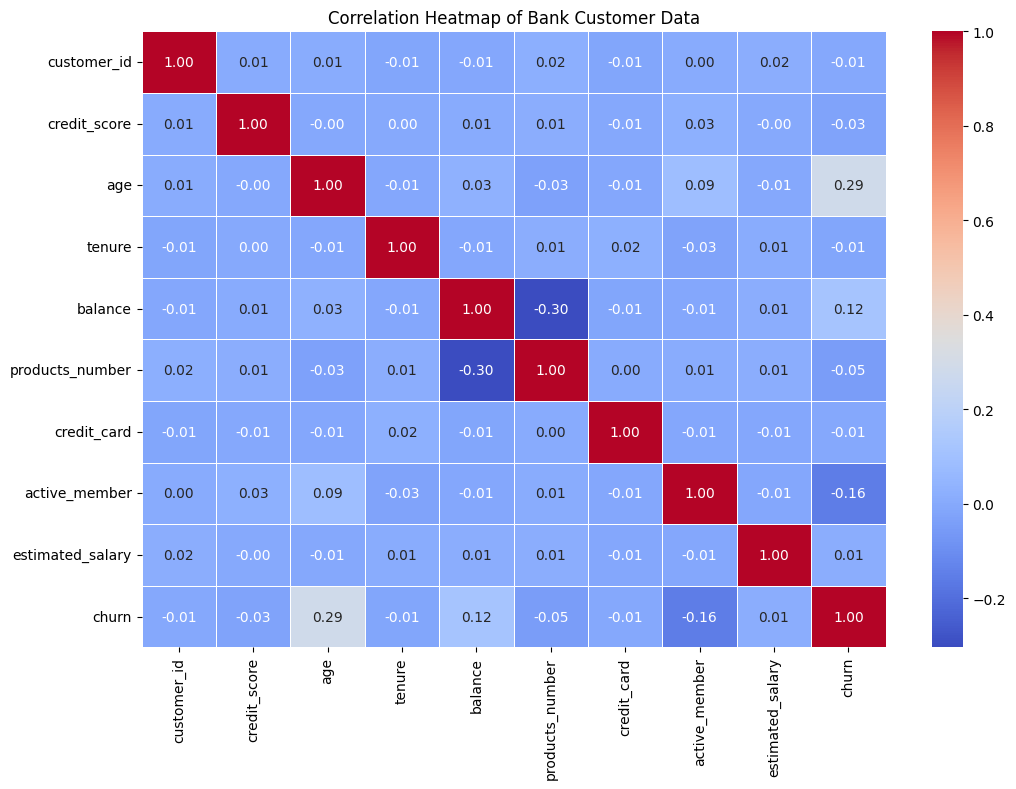

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Bank Customer Data')
plt.show()


In [13]:
df_model = df.drop(columns=['customer_id'])


In [14]:
X = df_model.drop(columns=['churn'])
y = df_model['churn']

In [15]:
X = pd.get_dummies(
    X,
    columns=['country', 'gender'],
    drop_first=True
)

X.head()


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
